# Lab A4 - Exception Handling in Imperative Programming - Kotlin
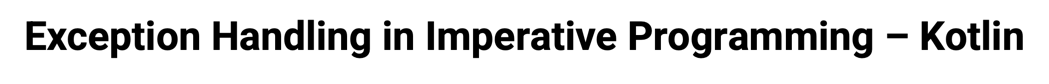

## Foundations
### Before Exercise 1: What is an enum?
An [enum](https://kotlinlang.org/docs/enum-classes.html) defines a fixed set of named choices. In this game:
```Kotlin
enum class Move { ROCK, PAPER, SCISSORS }
```
- A variable of type `Move` can hold one of those choices, such as `Move.ROCK`, `Move.values()` lists them in that order.

- Kotlin indexes the list from 0, so index 0 is `ROCK`, 1 is `PAPER`, and 2 is `SCISSORS`.

In [8]:
val playerMove: Move = Move.ROCK
println(playerMove)              // ROCK

if (playerMove == Move.ROCK) {
    println("The player chose rock.")
}

ROCK
The player chose rock.


In [9]:
val moves = Move.values()

println(moves[0])  // ROCK
println(moves[1])  // PAPER
println(moves[2])  // SCISSORS

ROCK
PAPER
SCISSORS


## Exercises

## Exercise 1: Rock–paper–scissors
**Goal**: Make the provided game respond clearly to invalid input and unexpected program states. The computer move and winner logic are already complete.

Instruction

1. **Convert the input safely**. Replace `toInt()` with `toIntOrNull()`. If the result is null, explicitly `throw` a `NumberFormatException` with a helpful message.
2. **Validate the choice**. Use `require()` to accept only 1, 2, or 3.

3. **Check the game setup**. Before generating the computer move, use check() to verify that Move contains exactly three values.



In [1]:
import kotlin.random.Random

enum class Move { ROCK, PAPER, SCISSORS }

fun parseMove(input: String): Move {
    // TODO 1: Replace toInt() with toIntOrNull().
    // If the result is null, throw a NumberFormatException
    // with a message explaining that a whole number is required.
    val number = input.toInt()

    // TODO 2: Use require() to accept only 1, 2, or 3.
    // Include a message telling the user which choices are valid.

    return when (number) {
        1 -> Move.ROCK
        2 -> Move.PAPER
        3 -> Move.SCISSORS
        else -> error("Unexpected move number: $number")
    }
}

fun generateComputerMove(): Move {
    val moves = Move.values()

    // TODO 3: Use check() to verify that moves contains
    // exactly three values before choosing a random move.

    return moves[Random.nextInt(3)]
}

fun determineWinner(player: Move, computer: Move): String = when {
    player == computer -> "It's a tie!"

    (player == Move.ROCK && computer == Move.SCISSORS) ||
            (player == Move.PAPER && computer == Move.ROCK) ||
            (player == Move.SCISSORS && computer == Move.PAPER) -> "You win!"

    else -> "Computer wins!"
}

fun main() {
    println("Enter your move:")
    println("1 = ROCK, 2 = PAPER, 3 = SCISSORS")

    try {
        val playerMove = parseMove(readln())
        val computerMove = generateComputerMove()

        println("You chose: $playerMove")
        println("Computer chose: $computerMove")
        println(determineWinner(playerMove, computerMove))

    } catch (e: NumberFormatException) {
        println("Input error: ${e.message}")
    } catch (e: IllegalArgumentException) {
        println("Choice error: ${e.message}")
    } catch (e: IllegalStateException) {
        println("Game error: ${e.message}")
    }
}

### Test
| Input or change | Expected behavior |
|---|---|
| `rock` | Explains that a whole number is required |
| `0` or `4` | Asks the user to choose `1`, `2`, or `3` |
| `1`, `2`, or `3` | Shows both moves and the result |


## Exercise 2: Keep Asking Until the Move Is Valid
Modify `readValidPlayerMove()` so it asks again after a non-number or a number outside 1..3. Once the input is valid, play one round.

### Excercise 3

#### Example using `check()`
Use `check()` when the program needs a particular state before it can continue. If the condition is false, Kotlin throws an `IllegalStateException  .


In [10]:
fun printDocument(printerReady: Boolean) {
    check(printerReady) { "The printer is not ready." }
    println("Printing document...")
}

In [11]:
printDocument(true)

Printing document...


Calling `printDocument(false)` stops before printing and `throws` an exception with the message “The printer is not ready.”

In [12]:
printDocument(false)

java.lang.IllegalStateException: The printer is not ready.

#### Exercise 3: Ticket booth
A ticket booth starts with five seats and may be `open` or `closed`. Complete the two TODOs:

In [13]:
var seatsRemaining = 5
var boothOpen = true

fun sellTickets(quantity: Int) {
    require(quantity > 0) { "Quantity must be positive." }

    // TODO 1: Use check() to stop the sale if boothOpen is false.
    // Give a message explaining that the booth is closed.

    // TODO 2: If quantity is greater than seatsRemaining,
    // explicitly throw an IllegalStateException.
    // Include the number of seats remaining in the message.

    seatsRemaining -= quantity
    println("Sold $quantity ticket(s). $seatsRemaining seats remain.")
}

**Test it**: Sell 2 tickets while the booth is open; then request 4 tickets; then set boothOpen = false and request 1. A failed sale must not reduce seatsRemaining.

### Exercise 4: Fahrenheit to Celsius with Safe Input

Write a program that asks the user for a temperature in Fahrenheit and prints its Celsius equivalent. The conversion formula is provided; your task is to convert and validate the input.
1. Replace `toDouble()` with `toDoubleOrNull()`. If conversion returns `null`, throw a `NumberFormatException` with a helpful message.
2. Use `require()` to reject temperatures below −459.67°F ([absolute zero](https://en.wikipedia.org/wiki/Absolute_zero)).
3. Run the tests below.

In [14]:
fun fahrenheitToCelsius(fahrenheit: Double): Double {
    // TODO 2: Use require() to check that fahrenheit is finite
    // and is at least -459.67.
    // Include a helpful error message.

    return (fahrenheit - 32.0) * 5.0 / 9.0
}

fun main() {
    println("Enter a temperature in Fahrenheit:")

    try {
        val input = readln()

        // TODO 1: Use toDoubleOrNull().
        // If conversion fails, throw a NumberFormatException
        // explaining that a number is required.
        val fahrenheit = input.toDouble()

        val celsius = fahrenheitToCelsius(fahrenheit)
        println("Celsius: $celsius")

    } catch (e: NumberFormatException) {
        println("Input error: ${e.message}")
    } catch (e: IllegalArgumentException) {
        println("Invalid temperature: ${e.message}")
    }
}

#### Test it

| Input | Expected behavior |
|---|---|
| `32` | Prints `0.0°C` |
| `212` | Prints `100.0°C` |
| `-40` | Prints `-40.0°C` |
| `hello` | Explains that a number is required |
| `-500` | Rejects a temperature below absolute zero |
| `Infinity` | Rejects a value that is not finite |